# EDA — Customer Churn (Entrega 1)
Análisis exploratorio sobre el **histórico completo** (solo exploración; el modelado usa el split reproducible de `src/data/split.py`).

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('../data/raw/customer_churn_historical.csv')
df['y'] = (df.Churn=='Yes').astype(int)
print(df.shape); df.dtypes

(7043, 22)


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
y                     int64
dtype: object

## 1. Calidad de datos

In [2]:
print('Duplicados customerID:', df.customerID.duplicated().sum(), '| filas duplicadas:', df.drop(columns='customerID').duplicated().sum())
na = df.isna().sum(); print(na[na>0])
df[df.TotalCharges.isna()][['tenure','MonthlyCharges','TotalCharges','Contract','Churn']].head(10)

Duplicados customerID: 0 | filas duplicadas: 0
TotalCharges    26
dtype: int64


,tenure,MonthlyCharges,TotalCharges,Contract,Churn
95,0,24.03,NaN,Month-to-month,No
781,0,83.01,NaN,Month-to-month,No
854,0,68.81,NaN,Month-to-month,No
867,0,75.01,NaN,Month-to-month,No
882,0,74.50,NaN,Month-to-month,Yes
1013,0,24.19,NaN,Month-to-month,Yes
1172,0,89.15,NaN,Two year,Yes
1842,0,89.85,NaN,Two year,No
2112,0,59.50,NaN,Month-to-month,Yes
2346,0,84.69,NaN,One year,Yes


Los 26 faltantes de `TotalCharges` son intencionales (README del paquete). Abajo se comprueba que **todos corresponden a `tenure = 0`** (clientes recién dados de alta, sin facturación acumulada): el valor semánticamente correcto es 0, no la mediana. Se imputa con `SimpleImputer(strategy='constant', fill_value=0)` **dentro del Pipeline**.

In [3]:
print(df[df.TotalCharges.isna()].tenure.describe())
ok = df.dropna(subset=['TotalCharges'])
print('corr(TotalCharges, tenure*MonthlyCharges) =', round(ok.TotalCharges.corr(ok.tenure*ok.MonthlyCharges),3))
df.describe().T

count    26.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: tenure, dtype: float64
corr(TotalCharges, tenure*MonthlyCharges) = 0.997


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.170098,0.375746,0.0,0.00,0.00,0.00,1.00
tenure,7043.0,35.168394,18.901478,0.0,20.00,35.00,51.00,72.00
MonthlyCharges,7043.0,68.168503,24.980659,18.0,55.36,73.91,88.00,114.41
TotalCharges,7017.0,2312.077586,1573.967858,0.0,986.63,2013.20,3452.85,7761.34
y,7043.0,0.263666,0.440652,0.0,0.00,0.00,1.00,1.00


## 2. Variable objetivo

Churn
No     5186
Yes    1857
Name: count, dtype: int64
Churn
No     0.736
Yes    0.264
Name: proportion, dtype: float64


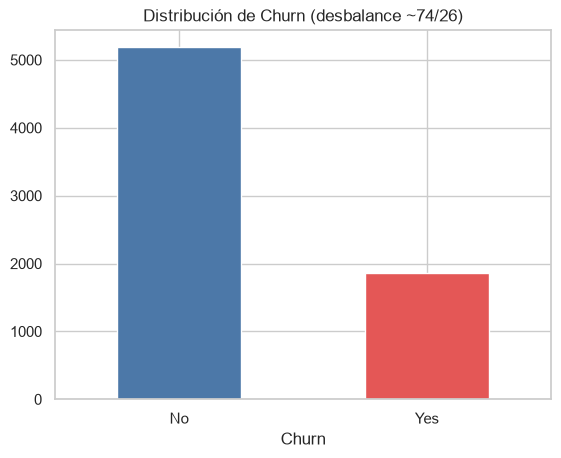

In [4]:
print(df.Churn.value_counts()); print(df.Churn.value_counts(normalize=True).round(3))
ax = df.Churn.value_counts().plot.bar(color=['#4c78a8','#e45756'], rot=0); ax.set_title('Distribución de Churn (desbalance ~74/26)')
plt.savefig('../reports/figures/target.png', dpi=110, bbox_inches='tight'); plt.show()

Desbalance moderado (~26 % churn): **accuracy no es una métrica válida** por sí sola (un modelo que dice siempre "No" tendría ~74 %). Usamos ROC-AUC, Precision/Recall/F1 y matriz de confusión.

## 3. Variables numéricas

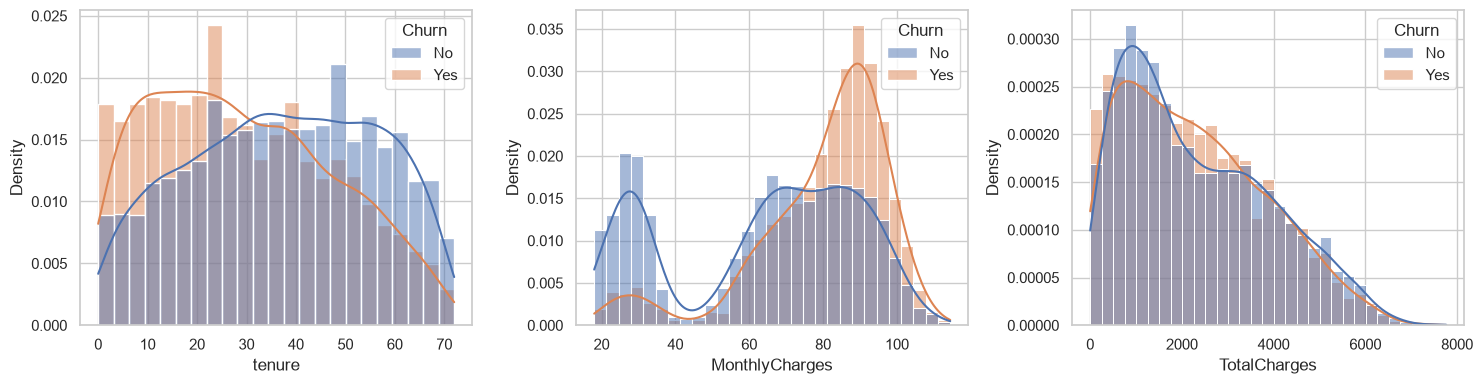

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,69.305,1986.725
Yes,27.0,84.690,2084.560


In [5]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
for a,c in zip(axes,['tenure','MonthlyCharges','TotalCharges']):
    sns.histplot(data=df, x=c, hue='Churn', kde=True, stat='density', common_norm=False, ax=a)
plt.tight_layout(); plt.savefig('../reports/figures/numericas.png', dpi=110); plt.show()
df.groupby('Churn')[['tenure','MonthlyCharges','TotalCharges']].median()

## 4. Variables categóricas vs. churn

C:\Users\cabre\AppData\Local\Temp\ipykernel_13780\3364697834.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cats = [c for c in df.select_dtypes('object') if c not in ('customerID','Churn')] + ['SeniorCitizen']


InternetService     0.326
Contract            0.298
OnlineSecurity      0.274
TechSupport         0.266
OnlineBackup        0.258
DeviceProtection    0.255
StreamingTV         0.253
StreamingMovies     0.247
PaymentMethod       0.080
SeniorCitizen       0.042
MultipleLines       0.033
Partner             0.031
Dependents          0.030
PaperlessBilling    0.029
PhoneService        0.025
gender              0.008
dtype: float64


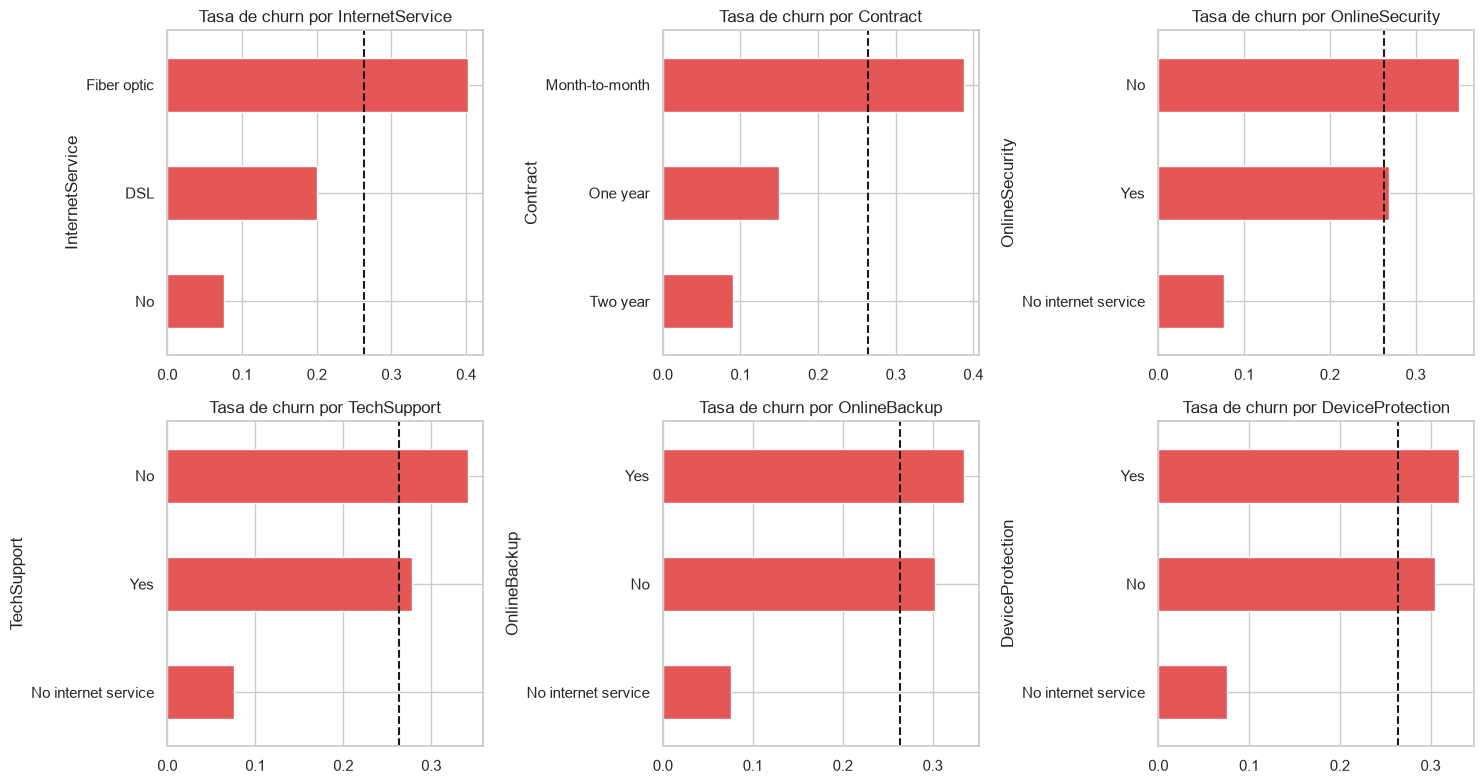

In [6]:
cats = [c for c in df.select_dtypes('object') if c not in ('customerID','Churn')] + ['SeniorCitizen']
rates = {c: df.groupby(c).y.mean() for c in cats}
spread = pd.Series({c:(r.max()-r.min()) for c,r in rates.items()}).sort_values(ascending=False)
print(spread.round(3))
top = spread.index[:6]
fig, axes = plt.subplots(2,3, figsize=(15,8))
for a,c in zip(axes.ravel(), top):
    rates[c].sort_values().plot.barh(ax=a, color='#e45756'); a.set_title(f'Tasa de churn por {c}'); a.axvline(df.y.mean(), ls='--', c='k')
plt.tight_layout(); plt.savefig('../reports/figures/categoricas.png', dpi=110); plt.show()

## 5. Correlaciones numéricas

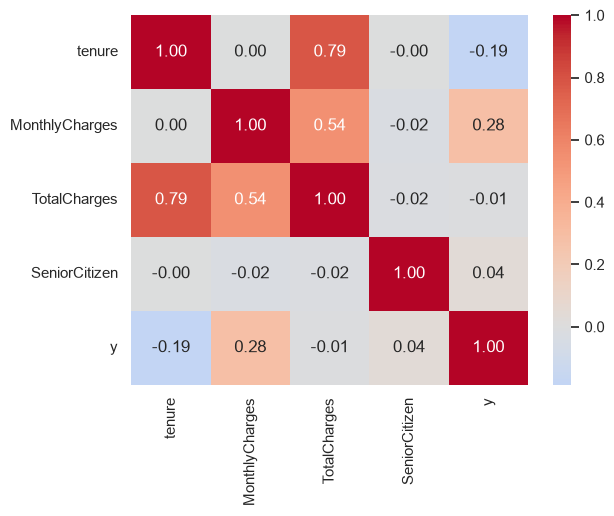

In [7]:
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges','SeniorCitizen','y']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.savefig('../reports/figures/correlacion.png', dpi=110, bbox_inches='tight'); plt.show()

## 6. Conclusiones del EDA
- 7.043 filas, 20 columnas predictoras + target; sin duplicados; único problema de calidad: 26 nulos en `TotalCharges`, todos con `tenure = 0` (imputación con 0 en el pipeline).
- `customerID` es identificador → se excluye (`remainder='drop'` en el ColumnTransformer).
- Target desbalanceado (~26 % churn) → métricas por clase, ROC-AUC y ajuste de threshold.
- Mayor poder discriminante: **Contract** (month-to-month ≈ 39 % de churn vs. ≈ 9 % en two-year), **InternetService** (fibra óptica ≈ 40 % vs. DSL ≈ 20 %), **tenure** (≈ 41 % de churn hasta 6 meses vs. ≈ 17 % con más de 48), y en menor medida ausencia de **TechSupport/OnlineSecurity** (≈ 35 %) y **PaymentMethod** electronic check (≈ 31 %).
- Variables de servicio con niveles "No internet service"/"No phone service" son redundantes con InternetService/PhoneService; se conservan y One-Hot las maneja sin problema.
- `gender`, `PaperlessBilling` y `SeniorCitizen` aportan poco (diferencias de 1–4 puntos porcentuales).